In [ ]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

carpeta_salidas = "outputs"
ruta_consumos = "../data/raw/consumos_uptc.csv"

# Crear carpeta de salida si no existe
if not os.path.exists(carpeta_salidas):
    os.makedirs(carpeta_salidas)

# Cargar dataset principal
df_consumos = pd.read_csv(ruta_consumos)
df_consumos["timestamp"] = pd.to_datetime(df_consumos["timestamp"])

filas, columnas = df_consumos.shape
print(f"Dataset cargado. Filas: {filas} | Columnas: {columnas}")


Dataset cargado: (275387, 26)
Iniciando análisis de correlaciones y anomalías...


MATRIZ DE CORRELACIONES
Gráfico guardado: outputs/matriz_correlaciones.png


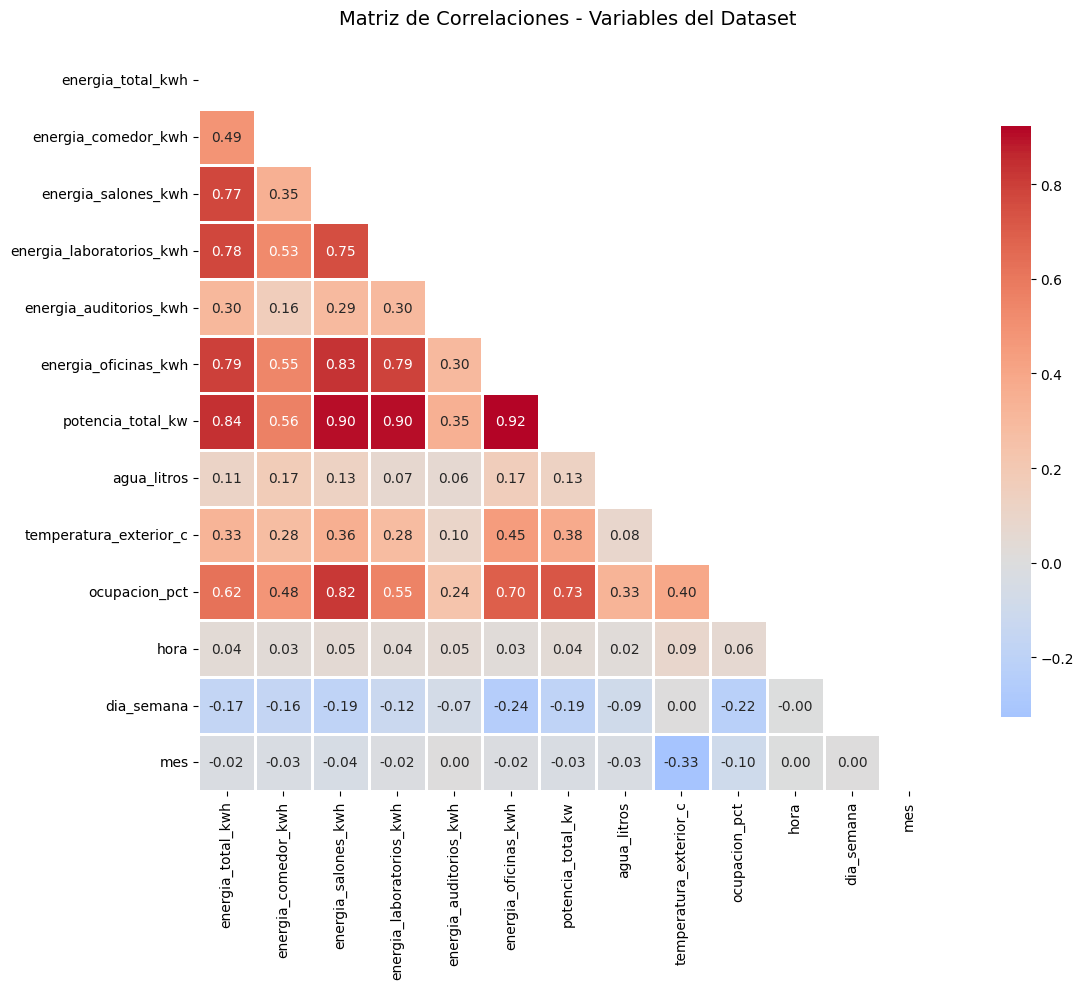


CORRELACIONES CON ENERGIA TOTAL:
energia_total_kwh           1.000000
potencia_total_kw           0.838346
energia_oficinas_kwh        0.794758
energia_laboratorios_kwh    0.775722
energia_salones_kwh         0.774939
ocupacion_pct               0.624136
energia_comedor_kwh         0.486873
temperatura_exterior_c      0.326215
energia_auditorios_kwh      0.303630
agua_litros                 0.112487
hora                        0.038307
mes                        -0.023359
dia_semana                 -0.166767
Name: energia_total_kwh, dtype: float64

CORRELACIONES MÁS FUERTES (|r| > 0.5):
energia_total_kwh           1.000000
potencia_total_kw           0.838346
energia_oficinas_kwh        0.794758
energia_laboratorios_kwh    0.775722
energia_salones_kwh         0.774939
ocupacion_pct               0.624136
Name: energia_total_kwh, dtype: float64


In [ ]:
# Matriz de correlaciones
print("Matriz de correlaciones")

columnas_correlacion = [
    "energia_total_kwh",
    "energia_comedor_kwh",
    "energia_salones_kwh",
    "energia_laboratorios_kwh",
    "energia_auditorios_kwh",
    "energia_oficinas_kwh",
    "potencia_total_kw",
    "agua_litros",
    "temperatura_exterior_c",
    "ocupacion_pct",
    "hora",
    "dia_semana",
    "mes",
]

# Filtrar solo columnas que existan en el dataset
columnas_existentes = [col for col in columnas_correlacion if col in df_consumos.columns]

matriz_correlacion = df_consumos[columnas_existentes].corr()

plt.figure(figsize=(14, 10))
mascara = np.triu(np.ones_like(matriz_correlacion, dtype=bool))

sns.heatmap(
    matriz_correlacion,
    mask=mascara,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8},
)

plt.title("Matriz de correlaciones - variables del dataset")
plt.tight_layout()

ruta_matriz = os.path.join(carpeta_salidas, "matriz_correlaciones.png")
plt.savefig(ruta_matriz, dpi=150, bbox_inches="tight")
plt.show()

print("Correlaciones con energia_total_kwh:")

correlaciones_energia = matriz_correlacion["energia_total_kwh"].sort_values(ascending=False)
print(correlaciones_energia)

correlaciones_fuertes = correlaciones_energia[correlaciones_energia.abs() > 0.5]
print("Correlaciones fuertes (valor absoluto mayor a 0.5):")
print(correlaciones_fuertes)


ANÁLISIS: TEMPERATURA vs ENERGÍA

Correlación global temperatura-energía: 0.3262

Correlación por sede:
  Chiquinquirá: 0.3642
  Duitama: 0.3523
  Sogamoso: 0.3283
  Tunja: 0.3417


C:\Users\migue\AppData\Local\Temp\ipykernel_26824\3192585798.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  energia_por_temp = df_temp.groupby(temp_bins)['energia_total_kwh'].mean()


Gráfico guardado: outputs/temperatura_vs_energia.png


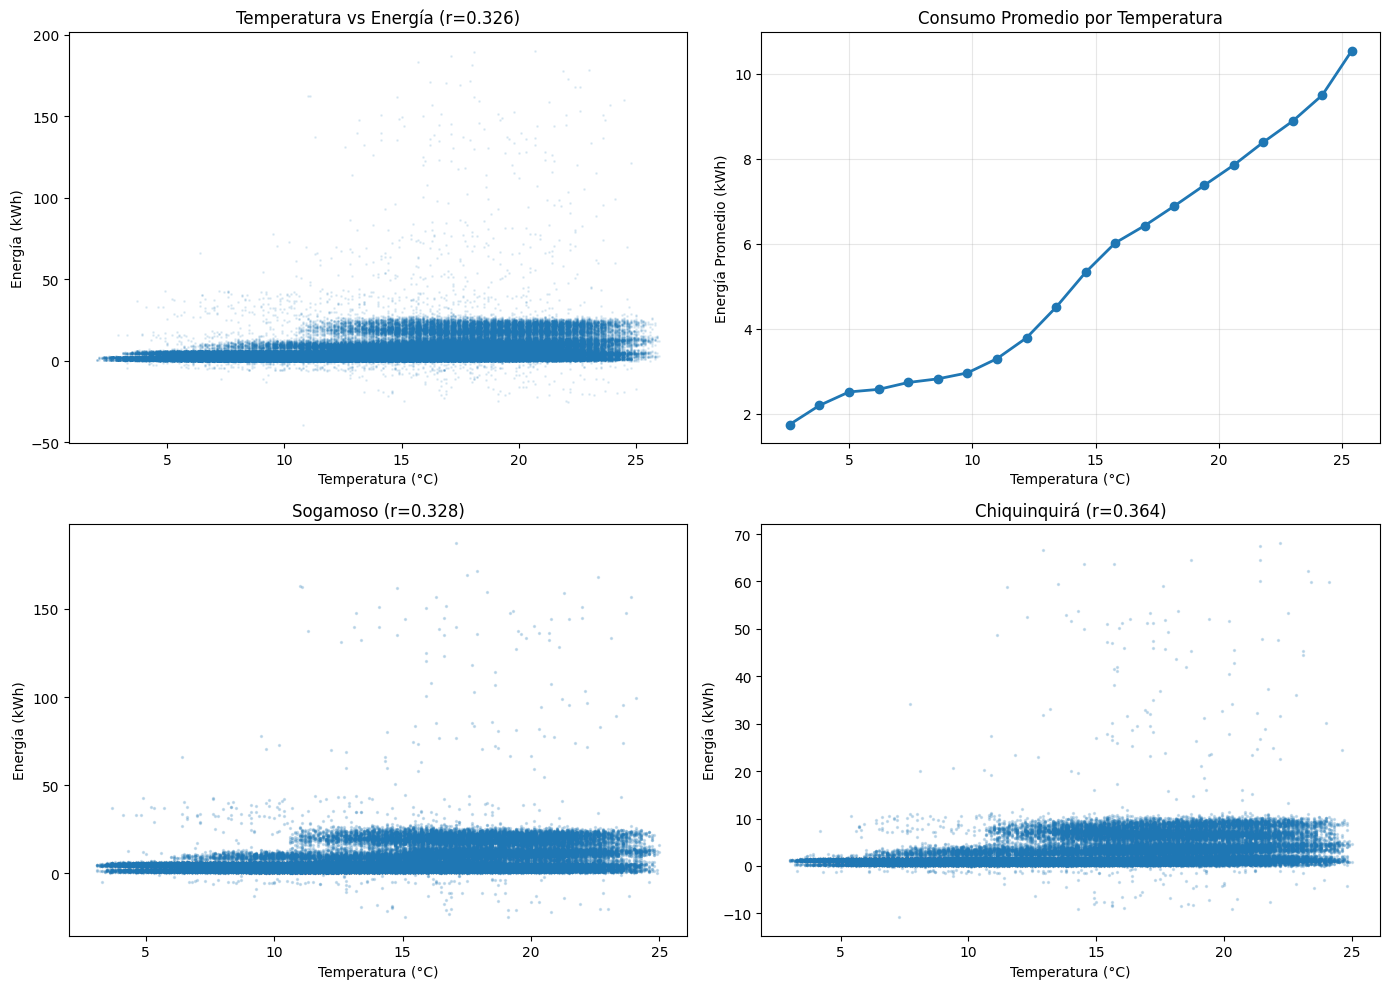

In [ ]:
# Temperatura vs energía
print("Análisis: temperatura vs energía")

df_temperatura = df_consumos[
    ["temperatura_exterior_c", "energia_total_kwh", "sede"]
].dropna()

correlacion_global_temp = df_temperatura["temperatura_exterior_c"].corr(
    df_temperatura["energia_total_kwh"]
)
print(f"Correlación global temperatura-energía: {correlacion_global_temp:.4f}")

print("Correlación por sede:")
for sede in df_temperatura["sede"].unique():
    datos_sede = df_temperatura[df_temperatura["sede"] == sede]
    correlacion_sede = datos_sede["temperatura_exterior_c"].corr(
        datos_sede["energia_total_kwh"]
    )
    print(f"{sede}: {correlacion_sede:.4f}")

fig, ejes = plt.subplots(2, 2, figsize=(14, 10))

# Dispersión global
ejes[0, 0].scatter(
    df_temperatura["temperatura_exterior_c"],
    df_temperatura["energia_total_kwh"],
    alpha=0.1,
    s=1,
)
ejes[0, 0].set_xlabel("Temperatura (°C)")
ejes[0, 0].set_ylabel("Energía (kWh)")
ejes[0, 0].set_title(f"Temperatura vs energía (r={correlacion_global_temp:.3f})")

# Promedio por rangos de temperatura
rangos_temp = pd.cut(df_temperatura["temperatura_exterior_c"], bins=20)
energia_promedio_temp = df_temperatura.groupby(rangos_temp)["energia_total_kwh"].mean()
centros_temp = [intervalo.mid for intervalo in energia_promedio_temp.index]

ejes[0, 1].plot(centros_temp, energia_promedio_temp.values, marker="o")
ejes[0, 1].set_xlabel("Temperatura (°C)")
ejes[0, 1].set_ylabel("Energía promedio (kWh)")
ejes[0, 1].set_title("Consumo promedio por temperatura")

# Gráficos por sede (solo dos para no saturar)
sedes_mostrar = df_temperatura["sede"].unique()[:2]

for idx, sede in enumerate(sedes_mostrar):
    datos_sede = df_temperatura[df_temperatura["sede"] == sede]
    eje = ejes[1, idx]
    corr_sede = datos_sede["temperatura_exterior_c"].corr(
        datos_sede["energia_total_kwh"]
    )

    eje.scatter(
        datos_sede["temperatura_exterior_c"],
        datos_sede["energia_total_kwh"],
        alpha=0.2,
        s=2,
    )
    eje.set_xlabel("Temperatura (°C)")
    eje.set_ylabel("Energía (kWh)")
    eje.set_title(f"{sede} (r={corr_sede:.3f})")

plt.tight_layout()

ruta_temp = os.path.join(carpeta_salidas, "temperatura_vs_energia.png")
plt.savefig(ruta_temp, dpi=150, bbox_inches="tight")
plt.show()

ANÁLISIS: OCUPACIÓN vs ENERGÍA

Correlación global ocupación-energía: 0.6241

Correlación por sede:
  Chiquinquirá: 0.7430
  Duitama: 0.7064
  Sogamoso: 0.6900
  Tunja: 0.7159


C:\Users\migue\AppData\Local\Temp\ipykernel_26824\2102482319.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  energia_por_ocup = df_ocup.groupby(ocup_bins)['energia_total_kwh'].mean()


Gráfico guardado: outputs/ocupacion_vs_energia.png


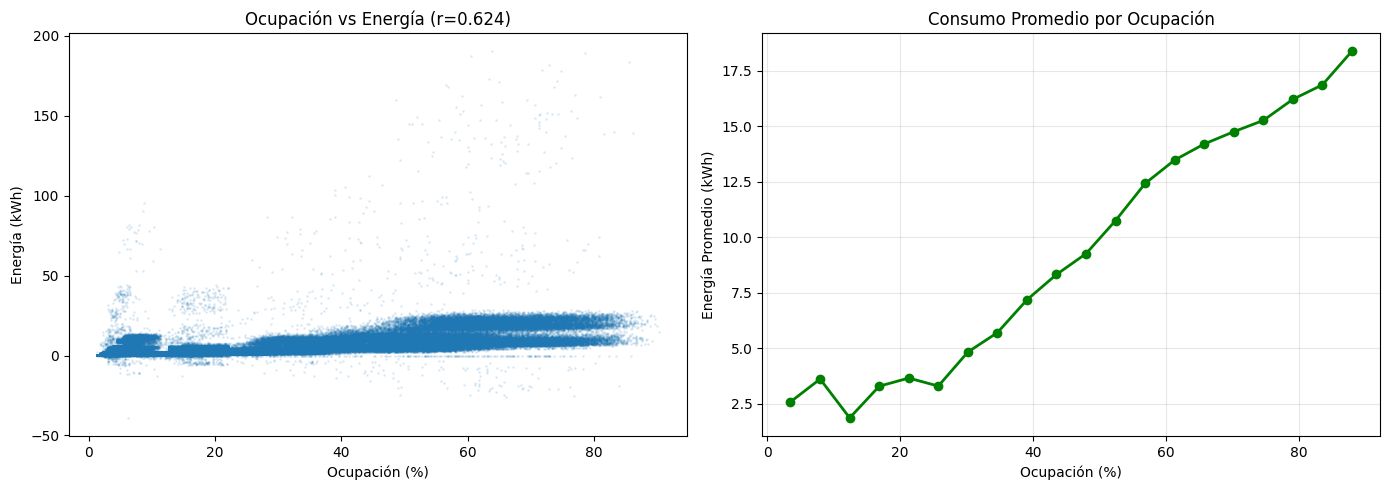

In [ ]:
# Ocupación vs energía (diferencias)
print("Analisis: ocupación vs energía")

df_ocupacion = df_consumos[["ocupacion_pct", "energia_total_kwh", "sede"]].dropna()

correlacion_ocupacion = df_ocupacion["ocupacion_pct"].corr(df_ocupacion["energia_total_kwh"])
print(f"Correlación global ocupación-energía: {correlacion_ocupacion:.4f}")

print("Correlación por sede:")
for sede in df_ocupacion["sede"].unique():
    datos_sede = df_ocupacion[df_ocupacion["sede"] == sede]
    corr_sede = datos_sede["ocupacion_pct"].corr(datos_sede["energia_total_kwh"])
    print(f"{sede}: {corr_sede:.4f}")

fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

# Dispersión
ejes[0].scatter(
    df_ocupacion["ocupacion_pct"],
    df_ocupacion["energia_total_kwh"],
    alpha=0.1,
    s=1,
)
ejes[0].set_xlabel("Ocupación (%)")
ejes[0].set_ylabel("Energía (kWh)")
ejes[0].set_title(f"Ocupación vs energía (r={correlacion_ocupacion:.3f})")

# Promedio por rangos de ocupación
rangos_ocupacion = pd.cut(df_ocupacion["ocupacion_pct"], bins=20)
energia_promedio_ocupacion = df_ocupacion.groupby(rangos_ocupacion)["energia_total_kwh"].mean()
centros_ocupacion = [intervalo.mid for intervalo in energia_promedio_ocupacion.index]

ejes[1].plot(centros_ocupacion, energia_promedio_ocupacion.values, marker="o")
ejes[1].set_xlabel("Ocupación (%)")
ejes[1].set_ylabel("Energía promedio (kWh)")
ejes[1].set_title("Consumo promedio por ocupación")

plt.tight_layout()

ruta_ocupacion = os.path.join(carpeta_salidas, "ocupacion_vs_energia.png")
plt.savefig(ruta_ocupacion, dpi=150, bbox_inches="tight")
plt.show()


ANÁLISIS: AGUA vs ENERGÍA

Correlación global agua-energía: 0.1125

Correlación por sede:
  Chiquinquirá: 0.6380
  Duitama: 0.6179
  Sogamoso: 0.4534
  Tunja: 0.6061
Gráfico guardado: outputs/agua_vs_energia.png


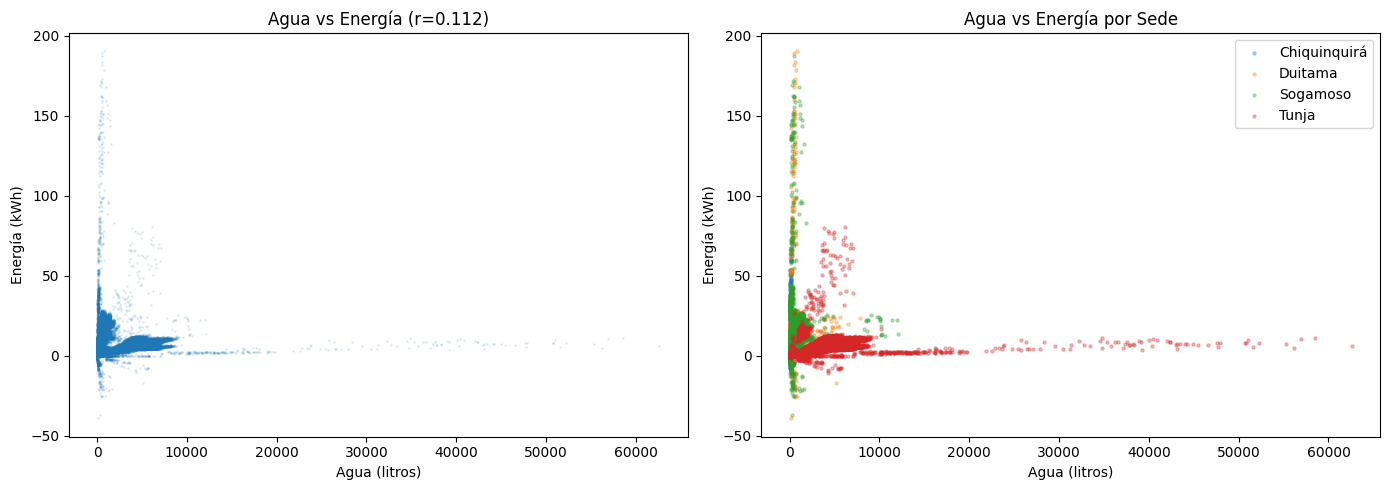

In [ ]:
# Agua vs energía
print("Analisis: agua vs energía")

df_agua = df_consumos[["agua_litros", "energia_total_kwh", "sede"]].dropna()

correlacion_agua = df_agua["agua_litros"].corr(df_agua["energia_total_kwh"])
print(f"Correlación global agua-energía: {correlacion_agua:.4f}")

print("Correlación por sede:")
for sede in df_agua["sede"].unique():
    datos_sede = df_agua[df_agua["sede"] == sede]
    corr_sede = datos_sede["agua_litros"].corr(datos_sede["energia_total_kwh"])
    print(f"{sede}: {corr_sede:.4f}")

fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

# Dispersión global
ejes[0].scatter(df_agua["agua_litros"], df_agua["energia_total_kwh"], alpha=0.1, s=1)
ejes[0].set_xlabel("Agua (litros)")
ejes[0].set_ylabel("Energía (kWh)")
ejes[0].set_title(f"Agua vs energía (r={correlacion_agua:.3f})")

# Dispersión por sede
for sede in df_agua["sede"].unique():
    datos_sede = df_agua[df_agua["sede"] == sede]
    ejes[1].scatter(
        datos_sede["agua_litros"],
        datos_sede["energia_total_kwh"],
        alpha=0.3,
        s=5,
        label=sede,
    )

ejes[1].set_xlabel("Agua (litros)")
ejes[1].set_ylabel("Energía (kWh)")
ejes[1].set_title("Agua vs energía por sede")
ejes[1].legend()

plt.tight_layout()

ruta_agua = os.path.join(carpeta_salidas, "agua_vs_energia.png")
plt.savefig(ruta_agua, dpi=150, bbox_inches="tight")
plt.show()


ANÁLISIS: ANOMALÍAS POR SECTOR

energia_comedor_kwh:
  Percentil 99: 2.32 kWh
  Máximo: 3.55 kWh
  Outliers (>Q99): 2672 (0.97%)

energia_salones_kwh:
  Percentil 99: 7.18 kWh
  Máximo: 9.53 kWh
  Outliers (>Q99): 2754 (1.00%)

energia_laboratorios_kwh:
  Percentil 99: 9.60 kWh
  Máximo: 39.68 kWh
  Outliers (>Q99): 2754 (1.00%)

energia_auditorios_kwh:
  Percentil 99: 1.36 kWh
  Máximo: 2.37 kWh
  Outliers (>Q99): 2618 (0.95%)

energia_oficinas_kwh:
  Percentil 99: 6.09 kWh
  Máximo: 7.82 kWh
  Outliers (>Q99): 2754 (1.00%)

Gráfico guardado: outputs/anomalias_por_sector.png


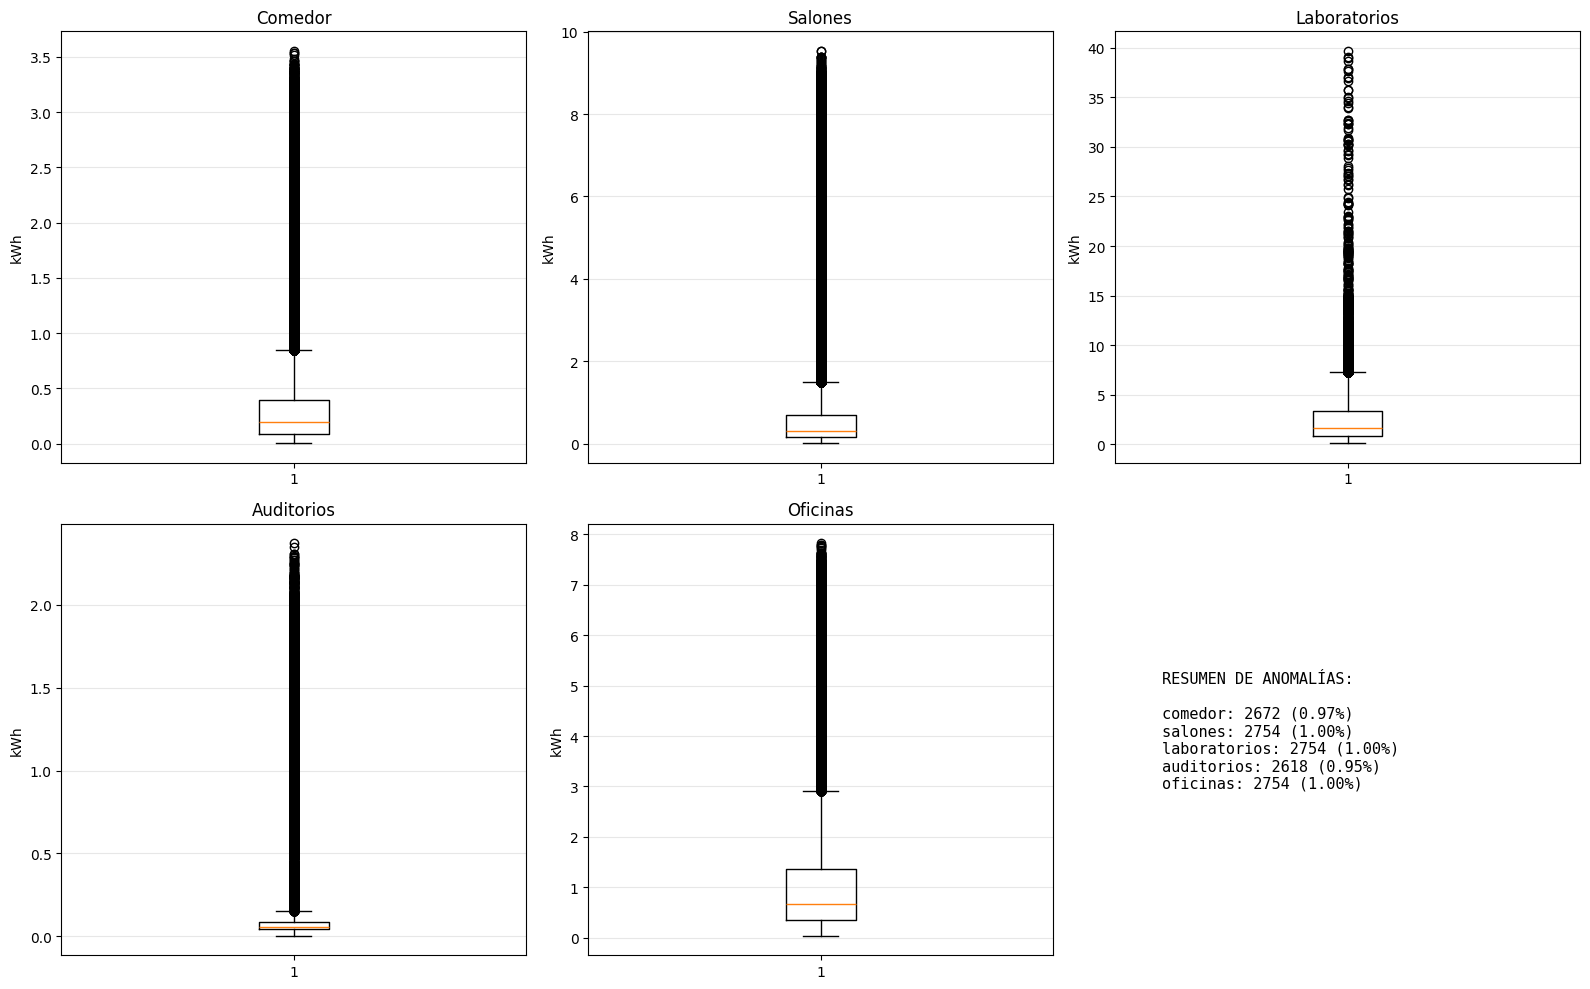

In [ ]:
# Anomalias por sector (outliers por percentil 99)
print("Analisis: Anomalias por sector")

columnas_sectores = [
    "energia_comedor_kwh",
    "energia_salones_kwh",
    "energia_laboratorios_kwh",
    "energia_auditorios_kwh",
    "energia_oficinas_kwh",
]
sectores_existentes = [col for col in columnas_sectores if col in df_consumos.columns]

anomalias_por_sector = {}

for sector in sectores_existentes:
    datos_sector = df_consumos[sector].dropna()
    percentil_99 = datos_sector.quantile(0.99)

    outliers_sector = df_consumos[df_consumos[sector] > percentil_99]
    porcentaje_outliers = (len(outliers_sector) / len(df_consumos)) * 100

    anomalias_por_sector[sector] = {
        "cantidad": len(outliers_sector),
        "porcentaje": porcentaje_outliers,
        "percentil_99": percentil_99,
        "maximo": datos_sector.max(),
    }

    print(f"{sector}")
    print(f"Percentil 99: {percentil_99:.2f} kWh")
    print(f"Máximo: {datos_sector.max():.2f} kWh")
    print(f"Outliers (> P99): {len(outliers_sector)} ({porcentaje_outliers:.2f}%)")

# Gráficas de boxplot (una por sector)
cantidad_sectores = len(sectores_existentes)
filas = 2
columnas = 3

fig, ejes = plt.subplots(filas, columnas, figsize=(16, 10))
ejes = ejes.flatten()

for idx, sector in enumerate(sectores_existentes):
    datos_sector = df_consumos[sector].dropna()
    ejes[idx].boxplot(datos_sector)
    nombre_corto = sector.replace("energia_", "").replace("_kwh", "").title()
    ejes[idx].set_title(nombre_corto)
    ejes[idx].set_ylabel("kWh")

# Cuadro de resumen en el último espacio
posicion_resumen = filas * columnas - 1
ejes[posicion_resumen].axis("off")

texto_resumen = "Resumen de Anomalias\n\n"
for sector, info in anomalias_por_sector.items():
    nombre = sector.replace("energia_", "").replace("_kwh", "")
    texto_resumen += f"{nombre}: {info['cantidad']} ({info['porcentaje']:.2f}%)\n"

ejes[posicion_resumen].text(0.05, 0.5, texto_resumen, verticalalignment="center")

plt.tight_layout()

ruta_anomalias = os.path.join(carpeta_salidas, "anomalias_por_sector.png")
plt.savefig(ruta_anomalias, dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Consumo nocturno (0 a 6)
print("Analisis: consumo nocturno (0 a 6)")

horas_nocturnas = [0, 1, 2, 3, 4, 5, 6]
df_nocturno = df_consumos[df_consumos["hora"].isin(horas_nocturnas)].copy()

print("Consumo nocturno promedio por sector:")
for sector in sectores_existentes:
    promedio_nocturno = df_nocturno[sector].mean()
    print(f"{sector}: {promedio_nocturno:.3f} kWh")

print("Casos sospechosos (nocturno > percentil 90 diurno)")

for sector in sectores_existentes:
    df_diurno = df_consumos[df_consumos["hora"].between(7, 22)]
    percentil_90_diurno = df_diurno[sector].quantile(0.90)

    sospechosos = df_nocturno[df_nocturno[sector] > percentil_90_diurno]
    porcentaje_sospechosos = (len(sospechosos) / len(df_nocturno)) * 100 if len(df_nocturno) > 0 else 0

    if len(sospechosos) > 0:
        print(f"{sector}")
        print(f"Percentil 90 diurno: {percentil_90_diurno:.2f} kWh")
        print(f"Casos nocturnos sobre ese valor: {len(sospechosos)} ({porcentaje_sospechosos:.2f}%)")

        print("Distribución por sede:")
        sedes_sospechosas = sospechosos["sede"].value_counts().head(4)
        for sede, cantidad in sedes_sospechosas.items():
            print(f"{sede}: {cantidad} casos")


ANÁLISIS: CONSUMO NOCTURNO (0-6 AM)

CONSUMO NOCTURNO PROMEDIO POR SECTOR:
  energia_comedor_kwh: 0.205 kWh
  energia_salones_kwh: 0.219 kWh
  energia_laboratorios_kwh: 1.730 kWh
  energia_auditorios_kwh: 0.066 kWh
  energia_oficinas_kwh: 0.464 kWh

CASOS SOSPECHOSOS (consumo nocturno anormalmente alto):

energia_laboratorios_kwh:
  P90 diurno: 6.45 kWh
  Casos nocturnos > P90 diurno: 116 (0.14%)
  Por sede:
    Duitama: 58 casos
    Sogamoso: 55 casos
    Tunja: 3 casos

energia_auditorios_kwh:
  P90 diurno: 0.11 kWh
  Casos nocturnos > P90 diurno: 3976 (4.95%)
  Por sede:
    Duitama: 3452 casos
    Chiquinquirá: 181 casos
    Sogamoso: 177 casos
    Tunja: 166 casos


ANÁLISIS: PATRONES POR DÍA DE SEMANA

CONSUMO PROMEDIO POR DÍA:
           dia_nombre      mean       std
dia_semana                               
0               Lunes  5.882244  6.811705
1              Martes  5.910092  7.024971
2           Miércoles  5.890436  6.855039
3              Jueves  5.837141  6.789547
4             Viernes  5.631918  6.446239
5              Sábado  3.745264  3.996714
6             Domingo  2.648929  2.197845

Gráfico guardado: outputs/patrones_dia_semana.png


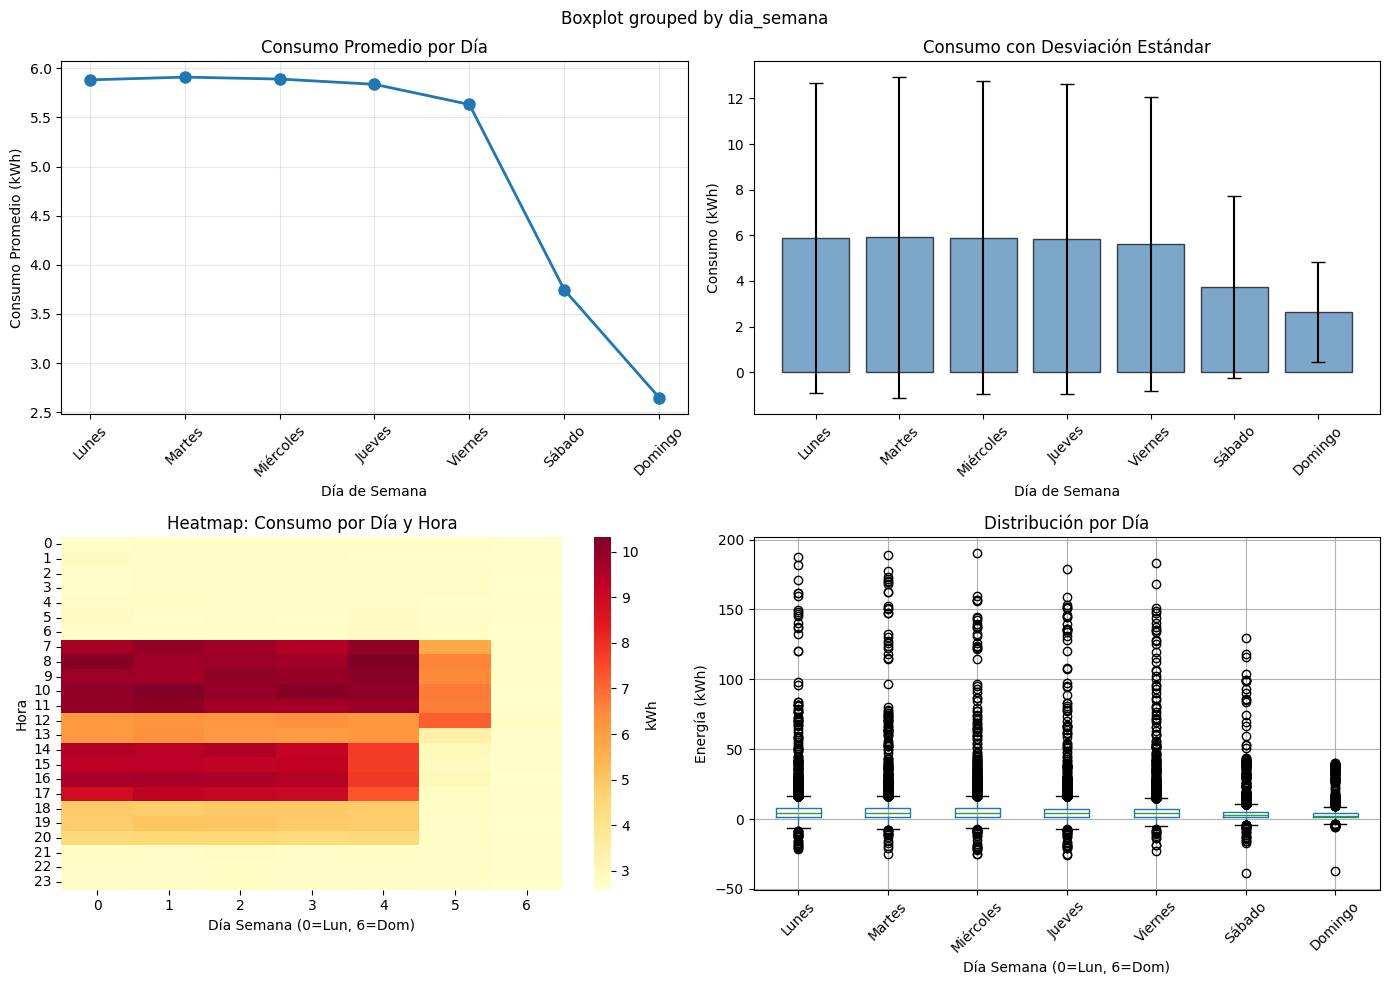

In [ ]:
# Patrones por día de semana
print("Analisis: patrones por día de semana")

mapa_dias = {
    0: "Lunes",
    1: "Martes",
    2: "Miércoles",
    3: "Jueves",
    4: "Viernes",
    5: "Sábado",
    6: "Domingo",
}

consumo_por_dia = df_consumos.groupby("dia_semana")["energia_total_kwh"].agg(["mean", "median", "std"])
consumo_por_dia["dia_nombre"] = consumo_por_dia.index.map(mapa_dias)

print("Consumo promedio por día:")
print(consumo_por_dia[["dia_nombre", "mean", "std"]])

fig, ejes = plt.subplots(2, 2, figsize=(14, 10))

# Línea
nombres_dias = [mapa_dias[i] for i in range(7)]
ejes[0, 0].plot(nombres_dias, consumo_por_dia["mean"].values, marker="o", linewidth=2)
ejes[0, 0].set_xlabel("Día de semana")
ejes[0, 0].set_ylabel("Consumo promedio (kWh)")
ejes[0, 0].set_title("Consumo promedio por día")
ejes[0, 0].tick_params(axis="x", rotation=45)

# Barras con desviación estándar
ejes[0, 1].bar(
    nombres_dias,
    consumo_por_dia["mean"].values,
    yerr=consumo_por_dia["std"].values,
    capsize=5,
    alpha=0.7,
    edgecolor="black",
)
ejes[0, 1].set_xlabel("Día de semana")
ejes[0, 1].set_ylabel("Consumo (kWh)")
ejes[0, 1].set_title("Consumo con desviación estándar")
ejes[0, 1].tick_params(axis="x", rotation=45)

# Heatmap día x hora
pivot_dia_hora = df_consumos.pivot_table(
    values="energia_total_kwh",
    index="hora",
    columns="dia_semana",
    aggfunc="mean",
)

sns.heatmap(pivot_dia_hora, ax=ejes[1, 0], cbar_kws={"label": "kWh"})
ejes[1, 0].set_xlabel("Día (0=Lun, 6=Dom)")
ejes[1, 0].set_ylabel("Hora")
ejes[1, 0].set_title("Consumo promedio por día y hora")

# Boxplot
df_consumos.boxplot(column="energia_total_kwh", by="dia_semana", ax=ejes[1, 1])
ejes[1, 1].set_xlabel("Día (0=Lun, 6=Dom)")
ejes[1, 1].set_ylabel("Energía (kWh)")
ejes[1, 1].set_title("Distribución por día")
plt.sca(ejes[1, 1])
plt.xticks([1, 2, 3, 4, 5, 6, 7], nombres_dias, rotation=45)

plt.tight_layout()

ruta_dia_semana = os.path.join(carpeta_salidas, "patrones_dia_semana.png")
plt.savefig(ruta_dia_semana, dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# Resumen final del analisis
print("Resumen final de analisis")

print("Correlaciones clave:")
if "correlacion_global_temp" in globals():
    print(f"Temperatura - Energía: {correlacion_global_temp:.4f}")
if "correlacion_ocupacion" in globals():
    print(f"Ocupación - Energía: {correlacion_ocupacion:.4f}")
if "correlacion_agua" in globals():
    print(f"Agua - Energía: {correlacion_agua:.4f}")

print("Anomalias por sector:")
if "anomalias_por_sector" in globals():
    for sector, info in anomalias_por_sector.items():
        nombre = sector.replace("energia_", "").replace("_kwh", "")
        print(f"{nombre}: {info['cantidad']} casos ({info['porcentaje']:.2f}%)")

print("Consumo nocturno:")
if "df_nocturno" in globals():
    promedio_nocturno = df_nocturno["energia_total_kwh"].mean()
    promedio_total = df_consumos["energia_total_kwh"].mean()
    ratio = (promedio_nocturno / promedio_total) if promedio_total != 0 else 0

    print(f"Promedio nocturno: {promedio_nocturno:.2f} kWh")
    print(f"Promedio total: {promedio_total:.2f} kWh")
    print(f"Relación nocturno / total: {ratio:.2%}")

print("Día de semana:")
mejor_dia = consumo_por_dia["mean"].idxmin()
peor_dia = consumo_por_dia["mean"].idxmax()

consumo_mejor = consumo_por_dia.loc[mejor_dia, "mean"]
consumo_peor = consumo_por_dia.loc[peor_dia, "mean"]

diferencia_pct = ((consumo_peor - consumo_mejor) / consumo_mejor * 100) if consumo_mejor != 0 else 0

print(f"Menor consumo: {mapa_dias[mejor_dia]} ({consumo_mejor:.2f} kWh)")
print(f"Mayor consumo: {mapa_dias[peor_dia]} ({consumo_peor:.2f} kWh)")
print(f"Diferencia: {diferencia_pct:.1f}%")


RESUMEN FINAL DE ANÁLISIS

1. CORRELACIONES CLAVE:
   - Temperatura-Energía: 0.3262
   - Ocupación-Energía: 0.6241
   - Agua-Energía: 0.1125

2. ANOMALÍAS POR SECTOR:
   - comedor: 2672 casos (0.97%)
   - salones: 2754 casos (1.00%)
   - laboratorios: 2754 casos (1.00%)
   - auditorios: 2618 casos (0.95%)
   - oficinas: 2754 casos (1.00%)

3. CONSUMO NOCTURNO:
   - Promedio nocturno: 2.73 kWh
   - vs Promedio total: 5.08 kWh
   - Ratio: 53.68%

4. DÍA DE SEMANA:
   - Menor consumo: Domingo (2.65 kWh)
   - Mayor consumo: Martes (5.91 kWh)
   - Diferencia: 123.1%

ANÁLISIS COMPLETO
Listo para proceder a limpieza de datos
